In [ ]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.transform import resize
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
df = pd.read_pickle("../project/Dataset.pkl")
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [3]:
def clean_nested_columns(df):
    # Rename the column with the original typo
    if 'trianTestLabel' in df.columns:
        df.rename(columns={'trianTestLabel': 'trainTestLabel'}, inplace=True)
    
    # Inner function to extract and format text
    def extract_text(value):
        while isinstance(value, (np.ndarray, list)):
            if len(value) == 0:
                return "unknown"
            value = value[0]
        
        # Return the clean string in lowercase (e.g., 'none', 'training', 'center')
        return str(value).lower()
    
    # Apply cleaning to label columns
    columns_to_fix = ['trainTestLabel', 'failureType']
    
    for col in columns_to_fix:
        if col in df.columns:
            df[col] = df[col].apply(extract_text)
            
    return df

df = clean_nested_columns(df)
df.head()

,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,training,none


# Wafer shapes

In [4]:
wafer_shapes = df['waferMap'].apply(lambda x: x.shape)
shape_counts = wafer_shapes.value_counts()
print(shape_counts)

print("\nTotal number of different shapes:")
print(len(shape_counts))

waferMap
(25, 27)     18781
(26, 26)     14366
(30, 34)     12400
(29, 26)     11751
(27, 25)     10682
             ...  
(68, 72)         1
(29, 45)         1
(38, 62)         1
(43, 133)        1
(36, 41)         1
Name: count, Length: 346, dtype: int64

Total number of different shapes:
346


In [5]:
def resize_wafer_maps(df, target_shape=(56, 56)):
    print(f"Ridimensionamento delle mappe dei wafer a {target_shape}...")
    
    resized_maps = []
    
    # Usiamo tqdm per vedere la barra di avanzamento
    for i in tqdm(range(len(df))):
        img = df['waferMap'].iloc[i]
        
        # Ridimensioniamo la matrice. 
        # order=0 indica un'interpolazione "nearest-neighbor", fondamentale per dati discreti 
        # (0, 1, 2) perché evita di creare sfumature con numeri decimali.
        img_resized = resize(img, target_shape, order=0, preserve_range=True, anti_aliasing=False)
        
        resized_maps.append(img_resized.astype(np.uint8))
        
    # Creiamo un unico grande array NumPy di forma (N_immagini, Altezza, Larghezza)
    X = np.array(resized_maps)
    
    # Aggiungiamo la dimensione del canale (1 per scala di grigi) richiesta dalle CNN
    X = np.expand_dims(X, axis=-1)
    
    return X

# Esegui il ridimensionamento (puoi scegliere 56x56 o 64x64 per un buon compromesso velocità/dettaglio)
X = resize_wafer_maps(df, target_shape=(56, 56))

print(f"\nFormato finale del tensore di input per la CNN: {X.shape}")

Ridimensionamento delle mappe dei wafer a (56, 56)...


100%|██████████| 172950/172950 [00:09<00:00, 18393.61it/s]



Formato finale del tensore di input per la CNN: (172950, 56, 56, 1)


# Label encoding

In [6]:
encoder = LabelEncoder()
# Transform the text column into a numeric array (y)
y = encoder.fit_transform(df['failureType'])

print(f"Encoded classes: {encoder.classes_}\n")

Encoded classes: ['center' 'donut' 'edge-loc' 'edge-ring' 'loc' 'near-full' 'none' 'random'
 'scratch']



# Balanced Undersampling (Capping) for ALL classes

In [7]:
MAX_SAMPLES_PER_CLASS = 3000
balanced_indices = []

np.random.seed(42) # For reproducibility

# Iterate through each unique class found in the dataset
for class_value in np.unique(y):
    # Find all indices belonging to this specific class
    class_indices = np.where(y == class_value)[0]
    
    # If the class has more images than our limit...
    if len(class_indices) > MAX_SAMPLES_PER_CLASS:
        # Randomly sample only MAX_SAMPLES_PER_CLASS
        sampled_indices = np.random.choice(class_indices, size=MAX_SAMPLES_PER_CLASS, replace=False)
    else:
        # If it has fewer (e.g., near-full), keep all of them
        sampled_indices = class_indices
        
    # Add these indices to our global list
    balanced_indices.extend(sampled_indices)

# Convert the list to a NumPy array
balanced_indices = np.array(balanced_indices)

# Randomly shuffle the new dataset to avoid ordered blocks
np.random.shuffle(balanced_indices)

# Creation of final balanced tensors

In [8]:
X_balanced = X[balanced_indices]
y_balanced = y[balanced_indices]

print("\n--- Dataset Ready and Perfectly Balanced ---")
print(f"X_balanced shape: {X_balanced.shape}")
print(f"y_balanced shape: {y_balanced.shape}")

# (Optional) Print the new distribution for confirmation
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nNew class distribution:")
for u, c in zip(unique, counts):
    print(f"{encoder.inverse_transform([u])[0]}: {c}")


--- Dataset Ready and Perfectly Balanced ---
X_balanced shape: (17763, 56, 56, 1)
y_balanced shape: (17763,)

New class distribution:
center: 3000
donut: 555
edge-loc: 3000
edge-ring: 3000
loc: 3000
near-full: 149
none: 3000
random: 866
scratch: 1193


In [9]:
# 1. Pixel Normalization
# Neural networks converge much faster and are more stable with values between 0 and 1
print("Normalizing pixel values...")
X_normalized = X_balanced.astype('float32') / 255.0

# 2. Train, Validation, and Test Split
# We use 'stratify' to ensure the class distribution remains consistent across all sets
# First split: 80% for Training, 20% for Validation/Test combined
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# Second split: Divide the remaining 20% equally into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 3. One-Hot Encoding for Labels
# Convert integer labels (e.g., 2) into probability arrays (e.g., [0, 0, 1, 0, 0, 0, 0, 0, 0])
num_classes = len(np.unique(y_balanced))

y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_val_categorical = to_categorical(y_val, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

print("\n--- Final Data Shapes ---")
print(f"Training set:   X: {X_train.shape}, y: {y_train_categorical.shape}")
print(f"Validation set: X: {X_val.shape}, y: {y_val_categorical.shape}")
print(f"Test set:       X: {X_test.shape}, y: {y_test_categorical.shape}")

Normalizing pixel values...

--- Final Data Shapes ---
Training set:   X: (14210, 56, 56, 1), y: (14210, 9)
Validation set: X: (1776, 56, 56, 1), y: (1776, 9)
Test set:       X: (1777, 56, 56, 1), y: (1777, 9)


In [10]:
def build_optimized_model(use_he=False, use_l2=False, optimizer_type='adam'):
    """
    Builds a flexible CNN model where specific optimizations can be toggled on or off.
    (Note: Data Augmentation is handled EXTERNALLY via ImageDataGenerator for DirectML compatibility).
    """
    INPUT_SHAPE = (56, 56, 1)
    NUM_CLASSES = 9
    
    model = Sequential(name="Flexible_Optimized_CNN")
        
    # --- TO-DO 2: He Initialization ---
    if use_he:
        print("-> Applying He Initialization")
        initializer = 'he_normal'
    else:
        initializer = 'glorot_uniform' # Default Keras initializer (Xavier)
        
    # --- TO-DO 4: L2 Regularization (Weight Decay) ---
    if use_l2:
        print("-> Applying L2 Regularization")
        regularizer = l2(0.001)
    else:
        regularizer = None

    # --- Block 1: Feature Extraction ---
    # Since augmentation is now handled externally, we ALWAYS need to define input_shape here
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same',
                     kernel_initializer=initializer, kernel_regularizer=regularizer, 
                     input_shape=INPUT_SHAPE))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same',
                     kernel_initializer=initializer, kernel_regularizer=regularizer))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same',
                     kernel_initializer=initializer, kernel_regularizer=regularizer))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # --- Block 2: Classification ---
    model.add(Flatten())

    model.add(Dense(128, activation='relu', 
                    kernel_initializer=initializer, kernel_regularizer=regularizer))
    model.add(Dropout(0.5))

    model.add(Dense(NUM_CLASSES, activation='softmax'))

    # --- TO-DO 1: Compare Optimizers ---
    if optimizer_type == 'sgd_momentum':
        print("-> Using SGD with Momentum Optimizer")
        opt = SGD(learning_rate=0.01, momentum=0.9)
    else:
        print("-> Using Adam Optimizer")
        opt = Adam(learning_rate=0.001)

    # Compile the Model
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [27]:
def plot_training_history(history_obj, experiment_name=""):
    print(f"Plotting learning curves for {experiment_name}...")
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history_obj.history['accuracy'], label='Train Accuracy', color='teal', linewidth=2)
    plt.plot(history_obj.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    plt.title(f'Model Accuracy - {experiment_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot Loss (Error)
    plt.subplot(1, 2, 2)
    plt.plot(history_obj.history['loss'], label='Train Loss', color='teal', linewidth=2)
    plt.plot(history_obj.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    plt.title(f'Model Loss - {experiment_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [16]:
# Initialize the Baseline model using our new optimized function
model_baseline = build_optimized_model(
    use_he=False, 
    use_l2=False, 
    optimizer_type='adam'
)
model_baseline.summary()

-> Using Adam Optimizer
Model: "Flexible_Optimized_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 56, 56, 32)        320       
                                                                 
 batch_normalization_9 (Batc  (None, 56, 56, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 28, 28, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 28, 28, 64)        18496     
                                                                 
 batch_normalization_10 (Bat  (None, 28, 28, 64)       256       
 chNormalization)                                                
                    

# Training Baseline Model

In [17]:
history_baseline = model_baseline.fit(
    X_train, 
    y_train_categorical,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_categorical),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath='baseline.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/50
221/223 [============================>.] - ETA: 0s - loss: 1.4186 - accuracy: 0.4769
Epoch 1: val_accuracy improved from -inf to 0.04842, saving model to baseline.h5
223/223 [==============================] - 2s 9ms/step - loss: 1.4170 - accuracy: 0.4774 - val_loss: 7.2521 - val_accuracy: 0.0484
Epoch 2/50
217/223 [============================>.] - ETA: 0s - loss: 0.9625 - accuracy: 0.6403
Epoch 2: val_accuracy improved from 0.04842 to 0.10529, saving model to baseline.h5
223/223 [==============================] - 2s 8ms/step - loss: 0.9654 - accuracy: 0.6400 - val_loss: 10.1712 - val_accuracy: 0.1053
Epoch 3/50
220/223 [============================>.] - ETA: 0s - loss: 0.8145 - accuracy: 0.6999
Epoch 3: val_accuracy improved from 0.10529 to 0.45664, saving model to baseline.h5
223/223 [==============================] - 2s 8ms/step - loss: 0.8131 - accuracy: 0.7007 - val_loss: 2.6930 - val_accuracy: 0.4566
Epoch 4/50
220/223 [============================>.] - ETA: 0s - loss:

# Training

Plotting learning curves for Baseline...


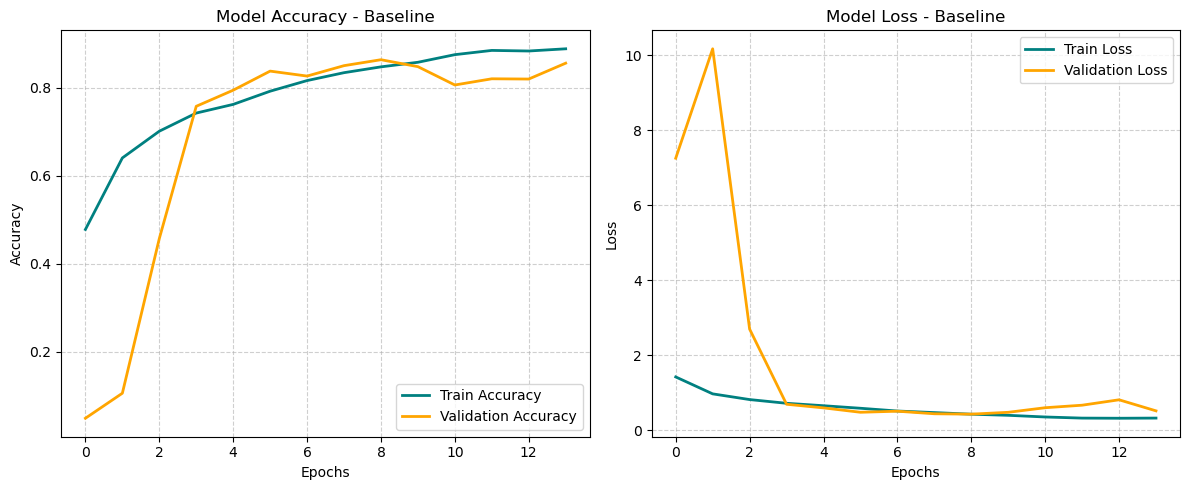

In [28]:
plot_training_history(history_baseline, experiment_name="Baseline")

# Test set

Evaluating model on Test Set...
56/56 [==============================] - 0s 4ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      center       0.96      0.98      0.97       300
       donut       0.95      0.73      0.82        55
    edge-loc       0.83      0.82      0.83       300
   edge-ring       0.98      0.95      0.96       300
         loc       0.73      0.78      0.75       300
   near-full       0.86      0.80      0.83        15
        none       0.79      0.91      0.85       300
      random       0.89      0.87      0.88        87
     scratch       0.59      0.39      0.47       120

    accuracy                           0.85      1777
   macro avg       0.84      0.80      0.82      1777
weighted avg       0.85      0.85      0.84      1777

Plotting Confusion Matrix...


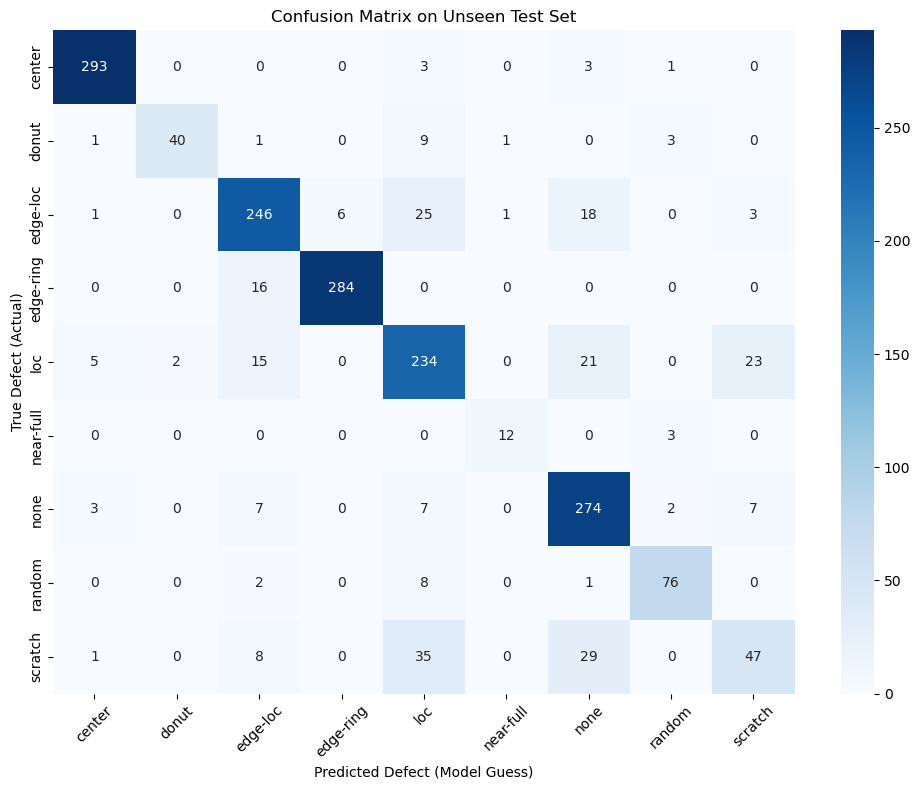

In [19]:
# 1. Get model predictions on the unseen Test Set
print("Evaluating model on Test Set...")
y_pred_probs = model_baseline.predict(X_test)

# Convert probability arrays back to class integers 
# (e.g., [0.1, 0.8, 0.1, ...] becomes class index 1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
# We retrieve the actual text names of the defects from our encoder
class_names = encoder.classes_

print("\n--- Classification Report ---")
# This will show Precision, Recall, and F1-Score for each specific defect
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
# We use a heatmap to visually highlight where the model makes mistakes
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix on Unseen Test Set')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Experiment 1: Only He Initialization

In [20]:
model_exp1 = build_optimized_model(
    use_he=True, 
    use_l2=False, 
    optimizer_type='adam'
)

# Define Callbacks with a RECOGNIZABLE file name
callbacks_exp1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    # Explicit and recognizable filename for this specific experiment
    ModelCheckpoint(filepath='exp1_he_initialization.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train the model
print("\nStarting training for Experiment 1...")
history_exp1 = model_exp1.fit(
    X_train, 
    y_train_categorical,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp1,
    verbose=1
)

-> Applying He Initialization
-> Using Adam Optimizer

Starting training for Experiment 1...
Epoch 1/50
217/223 [============================>.] - ETA: 0s - loss: 1.3892 - accuracy: 0.5131
Epoch 1: val_accuracy improved from -inf to 0.16892, saving model to exp1_he_initialization.h5
223/223 [==============================] - 2s 9ms/step - loss: 1.3830 - accuracy: 0.5148 - val_loss: 24.5925 - val_accuracy: 0.1689 - lr: 0.0010
Epoch 2/50
223/223 [==============================] - ETA: 0s - loss: 0.9722 - accuracy: 0.6327
Epoch 2: val_accuracy did not improve from 0.16892
223/223 [==============================] - 2s 8ms/step - loss: 0.9722 - accuracy: 0.6327 - val_loss: 14.9803 - val_accuracy: 0.1689 - lr: 0.0010
Epoch 3/50
219/223 [============================>.] - ETA: 0s - loss: 0.8214 - accuracy: 0.6983
Epoch 3: val_accuracy improved from 0.16892 to 0.49606, saving model to exp1_he_initialization.h5
223/223 [==============================] - 2s 9ms/step - loss: 0.8225 - accuracy: 0.6

Plotting learning curves for Exp 1 (He Init)...


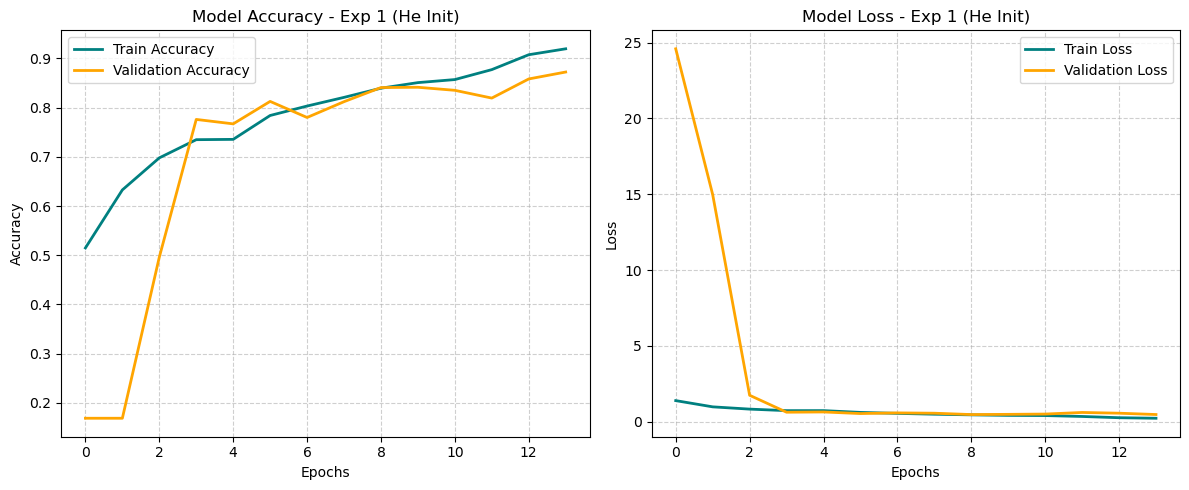

In [29]:
plot_training_history(history_exp1, experiment_name="Exp 1 (He Init)")

# Testing

Evaluating model on Test Set...
56/56 [==============================] - 0s 5ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      center       0.90      0.96      0.93       300
       donut       0.83      0.89      0.86        55
    edge-loc       0.80      0.81      0.81       300
   edge-ring       0.96      0.94      0.95       300
         loc       0.72      0.73      0.73       300
   near-full       1.00      0.40      0.57        15
        none       0.84      0.85      0.85       300
      random       0.78      0.89      0.83        87
     scratch       0.57      0.42      0.48       120

    accuracy                           0.83      1777
   macro avg       0.82      0.76      0.78      1777
weighted avg       0.82      0.83      0.82      1777

Plotting Confusion Matrix...


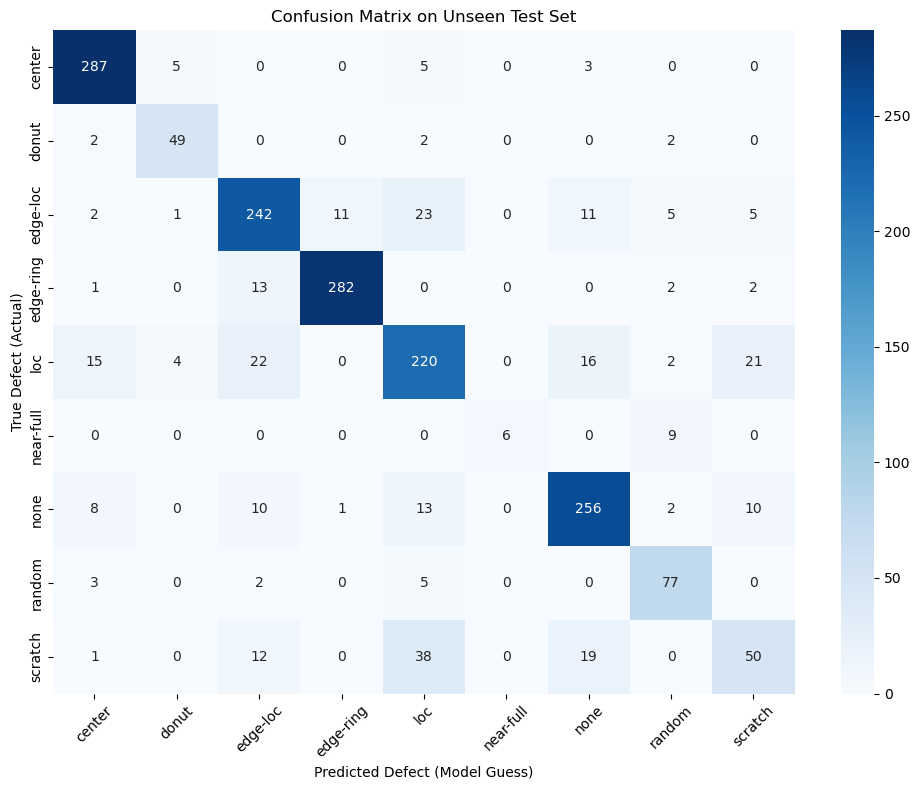

In [30]:
# 1. Get model predictions on the unseen Test Set
print("Evaluating model on Test Set...")
y_pred_probs = model_exp1.predict(X_test)

# Convert probability arrays back to class integers 
# (e.g., [0.1, 0.8, 0.1, ...] becomes class index 1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
# We retrieve the actual text names of the defects from our encoder
class_names = encoder.classes_

print("\n--- Classification Report ---")
# This will show Precision, Recall, and F1-Score for each specific defect
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
# We use a heatmap to visually highlight where the model makes mistakes
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix on Unseen Test Set')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EXPERIMENT 2: He Initialization + Data Augmentation

In [31]:
# 1. Build the model (He Initialization ON, L2 OFF)
model_exp2 = build_optimized_model(
    use_he=True, 
    use_l2=False, 
    optimizer_type='adam'
)

# 2. Create the "CPU Factory" for Data Augmentation
print("Setting up the ImageDataGenerator...")
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=72  # Randomly rotates the image up to 72 degrees
)

# 3. Define Callbacks
callbacks_exp2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    # Save this specific experiment's weights
    ModelCheckpoint(filepath='exp2_he_and_aug.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 4. Train the model using the generator
print("\nStarting training for Experiment 2...")
history_exp2 = model_exp2.fit(
    # We feed the generator which produces augmented batches on-the-fly
    datagen.flow(X_train, y_train_categorical, batch_size=64),
    epochs=50,
    # Validation data is NEVER augmented, we test on clean real data
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp2,
    verbose=1
)

-> Applying He Initialization
-> Using Adam Optimizer
Setting up the ImageDataGenerator...

Starting training for Experiment 2...
Epoch 1/50
222/223 [============================>.] - ETA: 0s - loss: 1.4142 - accuracy: 0.5163
Epoch 1: val_accuracy improved from -inf to 0.06700, saving model to exp2_he_and_aug.h5
223/223 [==============================] - 4s 17ms/step - loss: 1.4120 - accuracy: 0.5170 - val_loss: 41.1047 - val_accuracy: 0.0670 - lr: 0.0010
Epoch 2/50
222/223 [============================>.] - ETA: 0s - loss: 0.9760 - accuracy: 0.6377
Epoch 2: val_accuracy did not improve from 0.06700
223/223 [==============================] - 3s 14ms/step - loss: 0.9764 - accuracy: 0.6376 - val_loss: 23.8112 - val_accuracy: 0.0670 - lr: 0.0010
Epoch 3/50
222/223 [============================>.] - ETA: 0s - loss: 0.8859 - accuracy: 0.6779
Epoch 3: val_accuracy improved from 0.06700 to 0.51802, saving model to exp2_he_and_aug.h5
223/223 [==============================] - 3s 15ms/step - lo

Plotting learning curves for Exp 2 (He Init + Data Augmentation)...


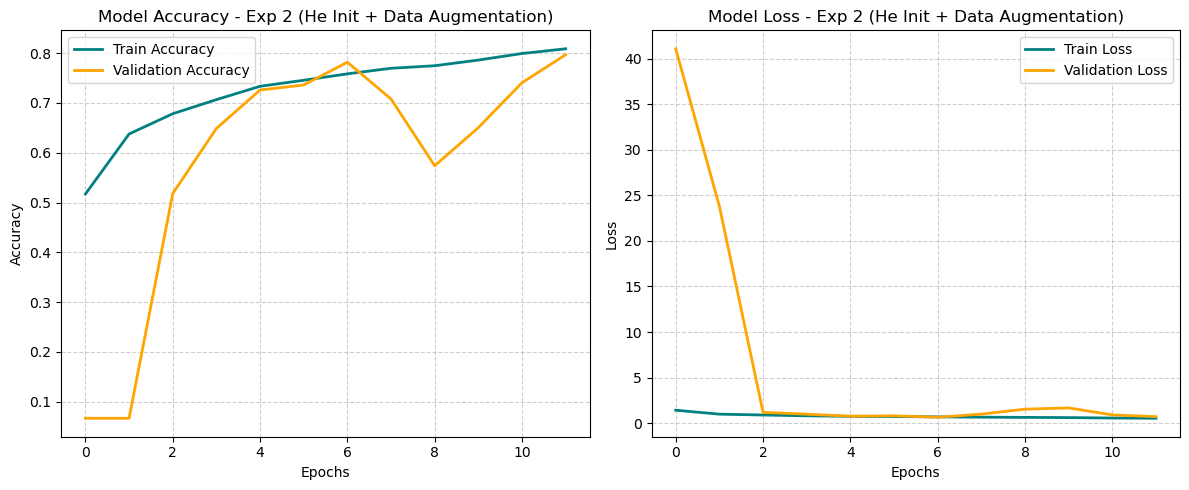

In [37]:
# Plot the learning curves for Experiment 2
plot_training_history(history_exp2, experiment_name="Exp 2 (He Init + Data Augmentation)")

Evaluating Exp 2 model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report (Exp 2) ---
              precision    recall  f1-score   support

      center       0.96      0.86      0.91       300
       donut       0.82      0.67      0.74        55
    edge-loc       0.74      0.67      0.70       300
   edge-ring       0.88      0.99      0.93       300
         loc       0.68      0.58      0.62       300
   near-full       1.00      0.60      0.75        15
        none       0.62      0.90      0.73       300
      random       0.62      0.98      0.76        87
     scratch       0.42      0.07      0.12       120

    accuracy                           0.75      1777
   macro avg       0.75      0.70      0.70      1777
weighted avg       0.75      0.75      0.73      1777

Plotting Confusion Matrix...


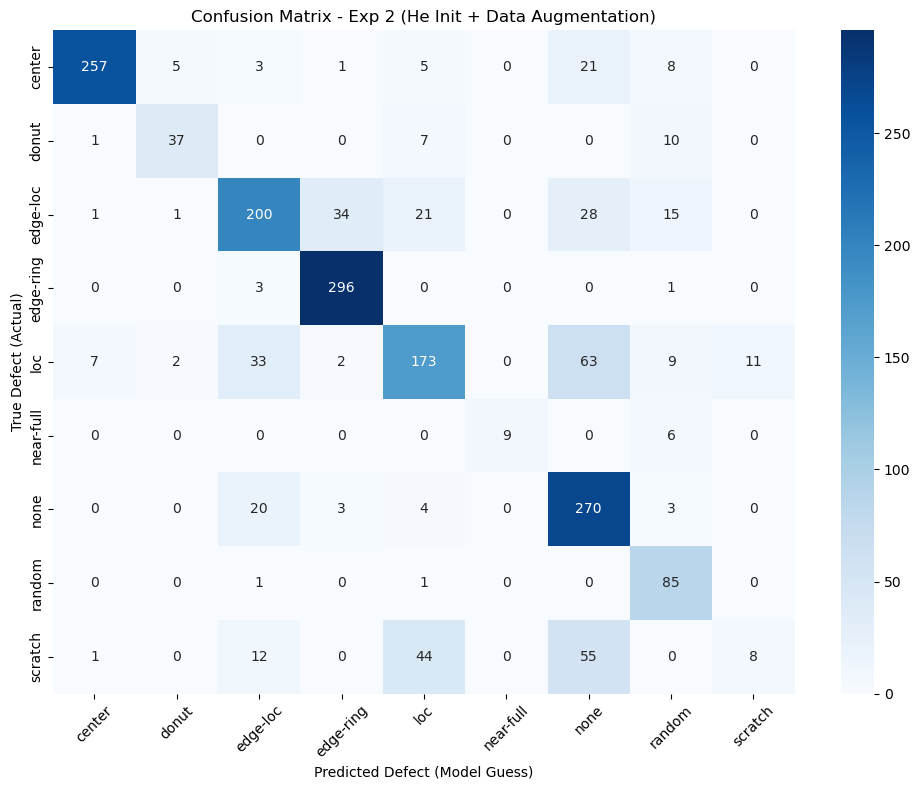

In [38]:
# 1. Get model predictions using the SPECIFIC model from Experiment 2
print("Evaluating Exp 2 model on Test Set...")
y_pred_probs_exp2 = model_exp2.predict(X_test)

# Convert probability arrays back to class integers 
y_pred_classes_exp2 = np.argmax(y_pred_probs_exp2, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
class_names = encoder.classes_

print("\n--- Classification Report (Exp 2) ---")
print(classification_report(y_true_classes, y_pred_classes_exp2, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm_exp2 = confusion_matrix(y_true_classes, y_pred_classes_exp2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_exp2, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Exp 2 (He Init + Data Augmentation)')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EXPERIMENT 3: He Init + Safe Flips + L2 Regularization

In [34]:
# 1. Build the model (He Init ON, L2 Regularization ON)
model_exp3 = build_optimized_model(
    use_he=True, 
    use_l2=True,
    optimizer_type='adam'
)

# 2. Create the "Safe CPU Factory" for Data Augmentation
print("Setting up the safe ImageDataGenerator...")
datagen_safe = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True
    # Rimosso rotation_range per evitare che l'interpolazione cancelli i graffi!
)

# 3. Define Callbacks
callbacks_exp3 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='exp3_safe_aug_l2.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 4. Train the model using the SAFE generator
print("\nStarting training for Experiment 3...")
history_exp3 = model_exp3.fit(
    datagen_safe.flow(X_train, y_train_categorical, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp3,
    verbose=1
)

-> Applying He Initialization
-> Applying L2 Regularization
-> Using Adam Optimizer
Setting up the safe ImageDataGenerator...

Starting training for Experiment 3...
Epoch 1/50
222/223 [============================>.] - ETA: 0s - loss: 2.1100 - accuracy: 0.4739
Epoch 1: val_accuracy improved from -inf to 0.00845, saving model to exp3_safe_aug_l2.h5
223/223 [==============================] - 3s 10ms/step - loss: 2.1077 - accuracy: 0.4746 - val_loss: 34.0746 - val_accuracy: 0.0084 - lr: 0.0010
Epoch 2/50
217/223 [============================>.] - ETA: 0s - loss: 1.6082 - accuracy: 0.5997
Epoch 2: val_accuracy improved from 0.00845 to 0.04786, saving model to exp3_safe_aug_l2.h5
223/223 [==============================] - 2s 9ms/step - loss: 1.6047 - accuracy: 0.6010 - val_loss: 13.4486 - val_accuracy: 0.0479 - lr: 0.0010
Epoch 3/50
220/223 [============================>.] - ETA: 0s - loss: 1.3395 - accuracy: 0.6854
Epoch 3: val_accuracy improved from 0.04786 to 0.56644, saving model to exp

Plotting learning curves for Exp 3 (He Init + Safe Aug + L2)...


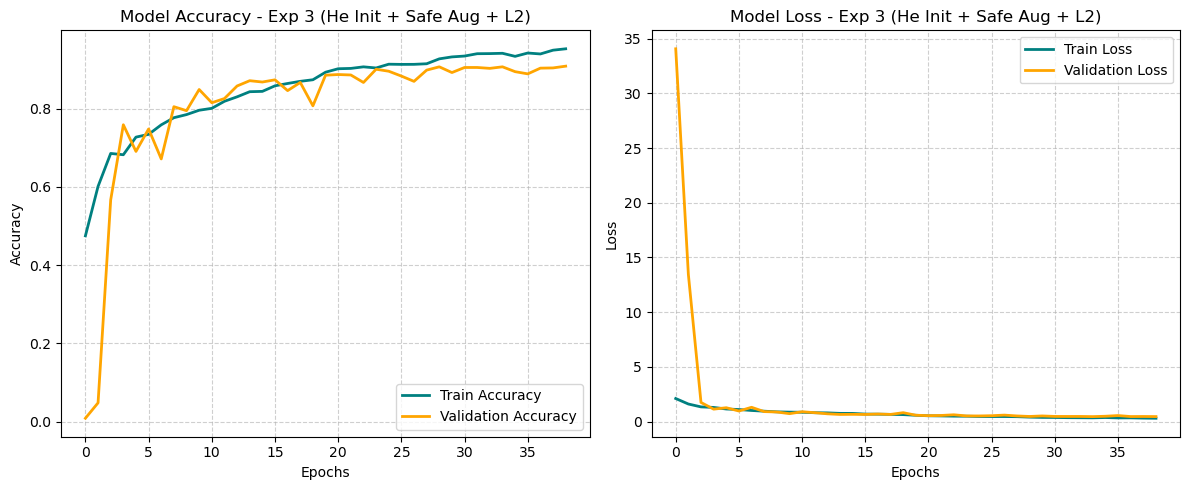

In [35]:
# Execute the plotting function using the history from Experiment 3
plot_training_history(history_exp3, experiment_name="Exp 3 (He Init + Safe Aug + L2)")

Evaluating Exp 3 model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report (Exp 3) ---
              precision    recall  f1-score   support

      center       0.95      0.97      0.96       300
       donut       0.88      0.84      0.86        55
    edge-loc       0.87      0.87      0.87       300
   edge-ring       0.99      0.97      0.98       300
         loc       0.82      0.81      0.81       300
   near-full       1.00      1.00      1.00        15
        none       0.88      0.91      0.89       300
      random       0.88      0.95      0.92        87
     scratch       0.90      0.79      0.84       120

    accuracy                           0.90      1777
   macro avg       0.91      0.90      0.90      1777
weighted avg       0.90      0.90      0.90      1777

Plotting Confusion Matrix...


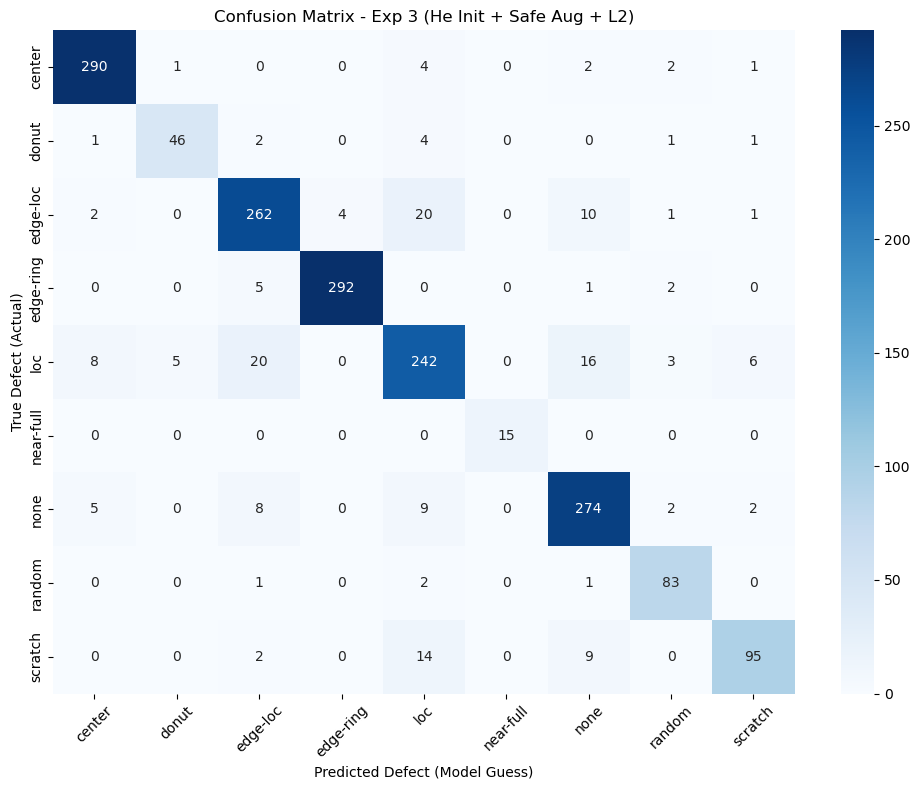

In [36]:
# 1. Get model predictions using the SPECIFIC model from Experiment 3
print("Evaluating Exp 3 model on Test Set...")
y_pred_probs_exp3 = model_exp3.predict(X_test)

# Convert probability arrays back to class integers 
y_pred_classes_exp3 = np.argmax(y_pred_probs_exp3, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
class_names = encoder.classes_

print("\n--- Classification Report (Exp 3) ---")
print(classification_report(y_true_classes, y_pred_classes_exp3, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm_exp3 = confusion_matrix(y_true_classes, y_pred_classes_exp3)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_exp3, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Exp 3 (He Init + Safe Aug + L2)')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support

print("--- FINAL MODEL COMPARISON ---")

# 1. Configurazione modelli per il caricamento dei pesi
models_config = {
    "Baseline CNN": {"file": "best_wafer_cnn.h5", "he": False, "l2": False},
    "Exp 1 (He Init)": {"file": "exp1_he_initialization.h5", "he": True, "l2": False},
    "Exp 2 (Bad Aug)": {"file": "exp2_he_and_aug.h5", "he": True, "l2": False},
    "Exp 3 (Safe Aug + L2)": {"file": "exp3_safe_aug_l2.h5", "he": True, "l2": True}
}

models_dict = {}
y_true = np.argmax(y_test_categorical, axis=1)
results_list = []
cm_dict = {}

# 2. Caricamento e Valutazione
for name, config in models_config.items():
    print(f"Loading and evaluating {name}...")
    model = build_optimized_model(use_he=config["he"], use_l2=config["l2"])
    model.load_weights(config["file"])
    models_dict[name] = model
    
    # Previsioni
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Metriche
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred) # Nuova metrica aggiunta
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    
    results_list.append({
        "Model": name, 
        "Accuracy": round(acc * 100, 2), 
        "Balanced Accuracy": round(bal_acc * 100, 2), 
        "F1-Score": round(f1 * 100, 2)
    })
    cm_dict[name] = confusion_matrix(y_true, y_pred)

# 3. Tabella Risultati
benchmark_df = pd.DataFrame(results_list).set_index("Model")
display(benchmark_df)

--- FINAL MODEL COMPARISON ---
Loading and evaluating Baseline CNN...
-> Using Adam Optimizer
Loading and evaluating Exp 1 (He Init)...
-> Applying He Initialization
-> Using Adam Optimizer
Loading and evaluating Exp 2 (Bad Aug)...
-> Applying He Initialization
-> Using Adam Optimizer
Loading and evaluating Exp 3 (Safe Aug + L2)...
-> Applying He Initialization
-> Applying L2 Regularization
-> Using Adam Optimizer


,Accuracy,Balanced Accuracy,F1-Score
Model,,,
Baseline CNN,82.05,76.10,76.69
Exp 1 (He Init),82.67,76.47,77.71
Exp 2 (Bad Aug),75.13,70.03,69.52
Exp 3 (Safe Aug + L2),89.98,90.17,90.39


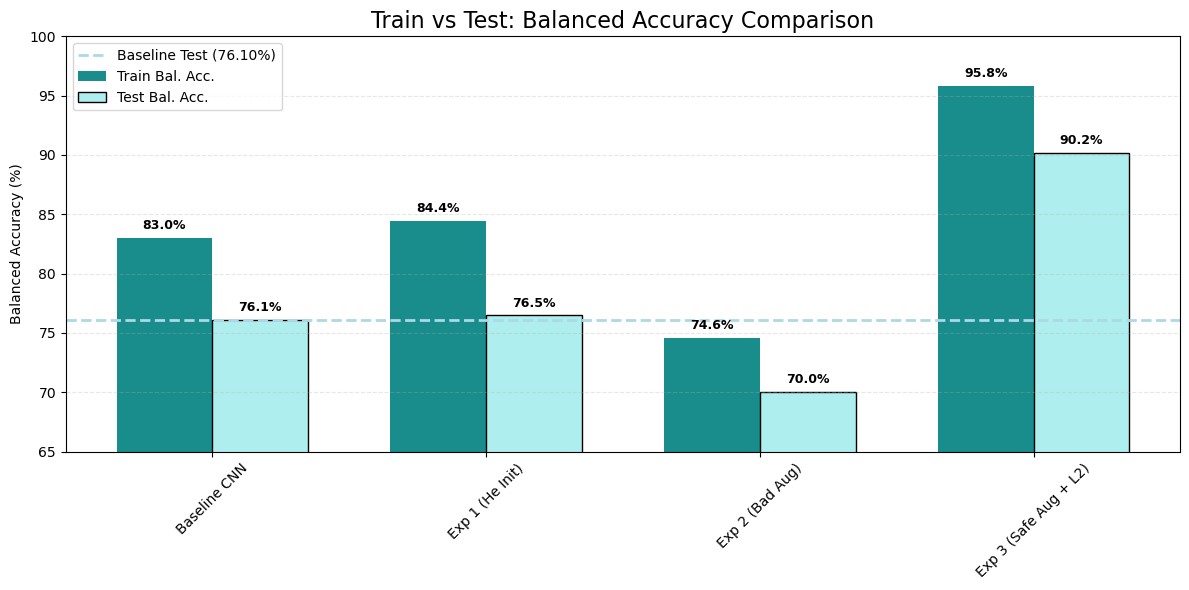

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepariamo i dati per il confronto (Train vs Test)
train_scores = []
test_scores = []
model_names = list(models_dict.keys())

for name in model_names:
    model = models_dict[name]
    
    # Valutazione Train
    y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    y_train_true = np.argmax(y_train_categorical, axis=1)
    train_scores.append(balanced_accuracy_score(y_train_true, y_train_pred) * 100)
    
    # Valutazione Test
    y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_scores.append(balanced_accuracy_score(y_true, y_test_pred) * 100)

# 2. Setup grafico a doppia barra
x = np.arange(len(model_names))
width = 0.35 

plt.figure(figsize=(12, 6))

# Barre chiare (Test) e scure (Train)
rects1 = plt.bar(x - width/2, train_scores, width, label='Train Bal. Acc.', color='teal', alpha=0.9)
rects2 = plt.bar(x + width/2, test_scores, width, label='Test Bal. Acc.', color='paleturquoise', edgecolor='black')

# Linea Baseline (usa il valore di Test della Baseline)
plt.axhline(y=test_scores[0], color='lightblue', linestyle='--', linewidth=2, label=f'Baseline Test ({test_scores[0]:.2f}%)')

# 3. Formattazione
plt.ylim(65, 100)
plt.ylabel('Balanced Accuracy (%)')
plt.title('Train vs Test: Balanced Accuracy Comparison', fontsize=16)
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Funzione per aggiungere le etichette sopra le barre
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

add_labels(rects1)
add_labels(rects2)

plt.tight_layout()
plt.show()